In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from functions import fingerprint
import pandas as pd


/home/benix/Workspace/terracettes/functions.py:227: RuntimeWarning: invalid value encountered in divide
  coherence = np.where(G_xx + G_yy == 0, 0, np.sqrt(((G_xx - G_yy)**2) + (4*(G_xy**2))) / (G_xx + G_yy))
/home/benix/Workspace/terracettes/functions.py:230: RuntimeWarning: invalid value encountered in divide
  theta = np.arctan(Vj/Vi)%(np.pi)


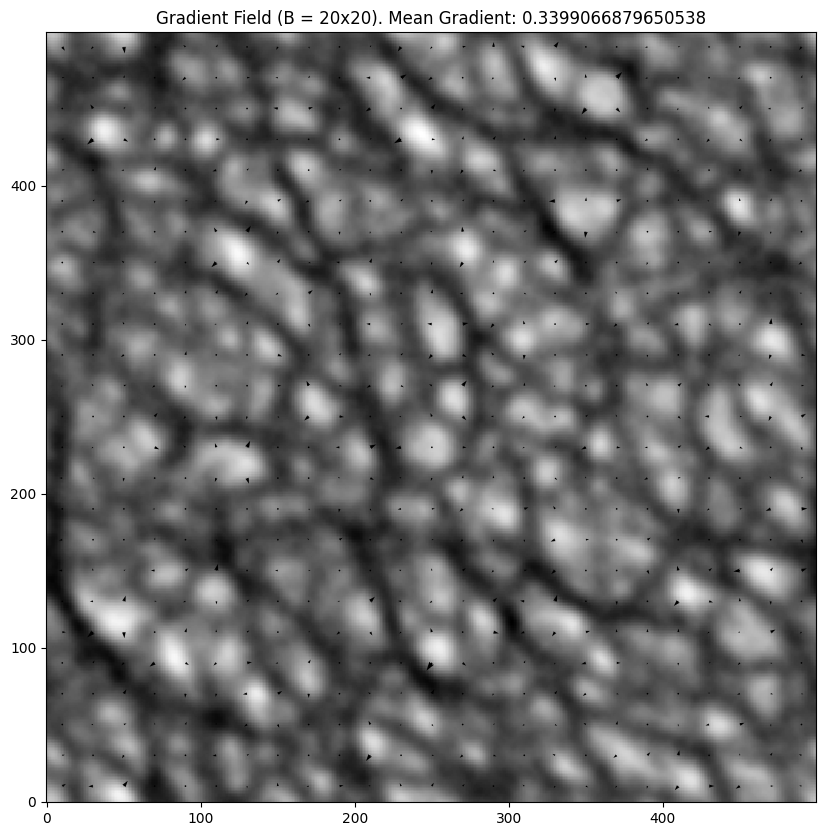

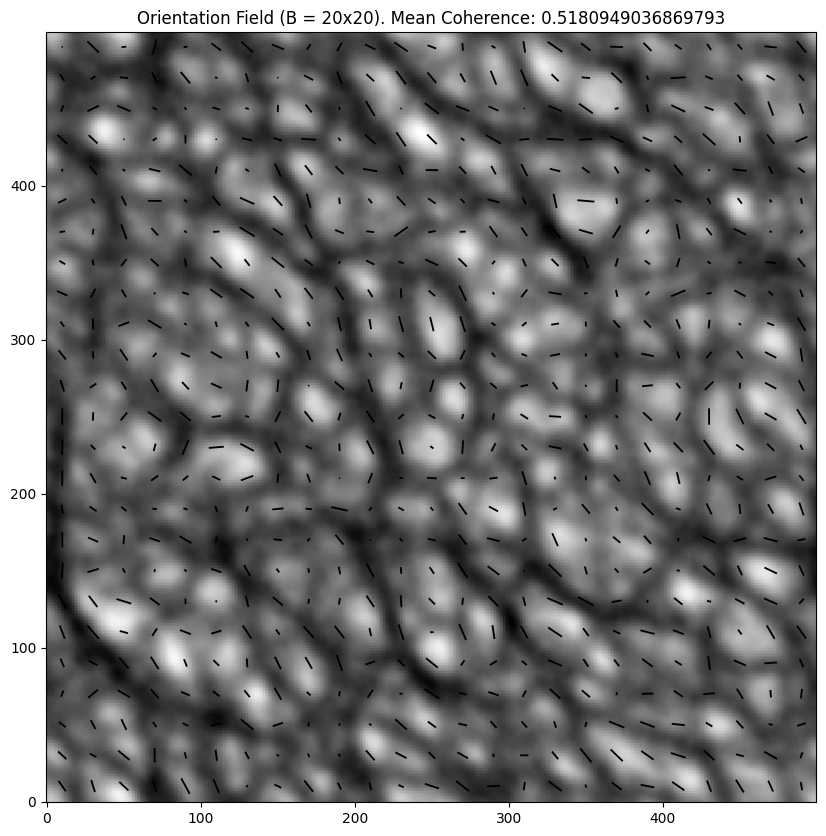

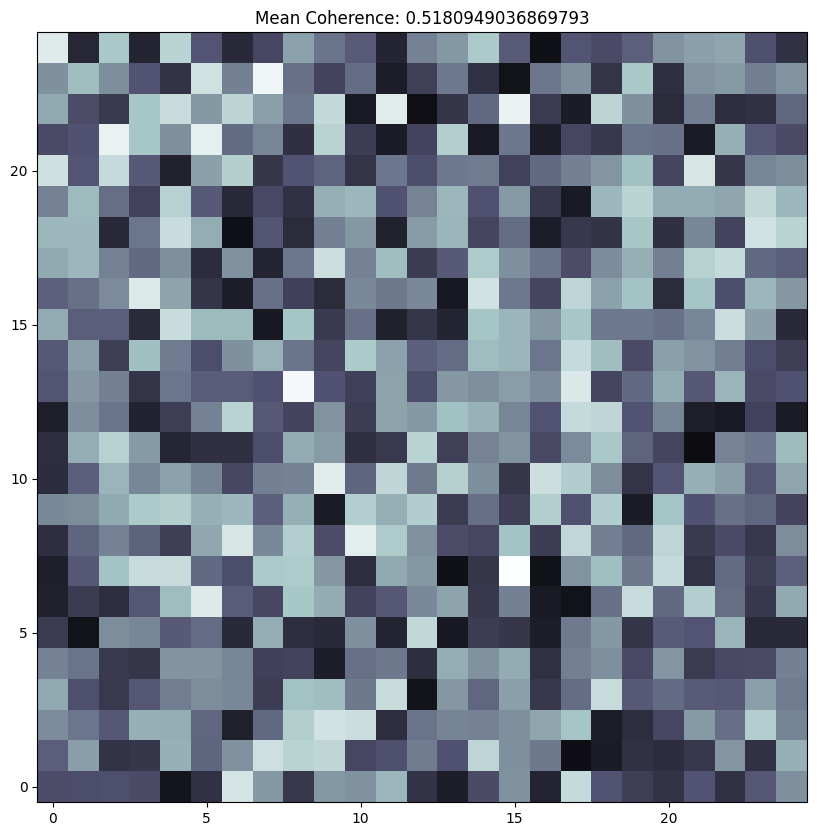

0.5180949036869793


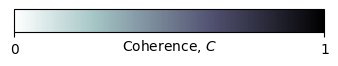

In [ ]:
np_df = np.genfromtxt('SIfig05/results.csv', delimiter=',')
elevation_map = np.load(f'SIfig05/maps/elevation_map_0.npy')
trampled = np.load(f'SIfig05/maps/trampled_0_50_3_9.npy')
total_erosion = trampled-elevation_map
total_erosion = (total_erosion - np.max(total_erosion))

omega = 20
theta, mean_gradient, mean_coherence = fingerprint(total_erosion, omega, ground_truth=None, plot=True)
print(mean_coherence)

cmap = plt.cm.bone_r  # Replace with your chosen colormap
norm = mpl.colors.Normalize(vmin=0, vmax=1)  # Assuming min_erosion and max_erosion are defined

# Create a standalone colorbar figure
fig, ax = plt.subplots(figsize=(4, 0.6))
fig.subplots_adjust(bottom=0.5)  # Adjust layout for better placement

# Create a colorbar
labels = np.array([0, 1])

cbar = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal', ticks=labels)

# Add a label
cbar.set_label('Coherence, $C$', labelpad=-13)

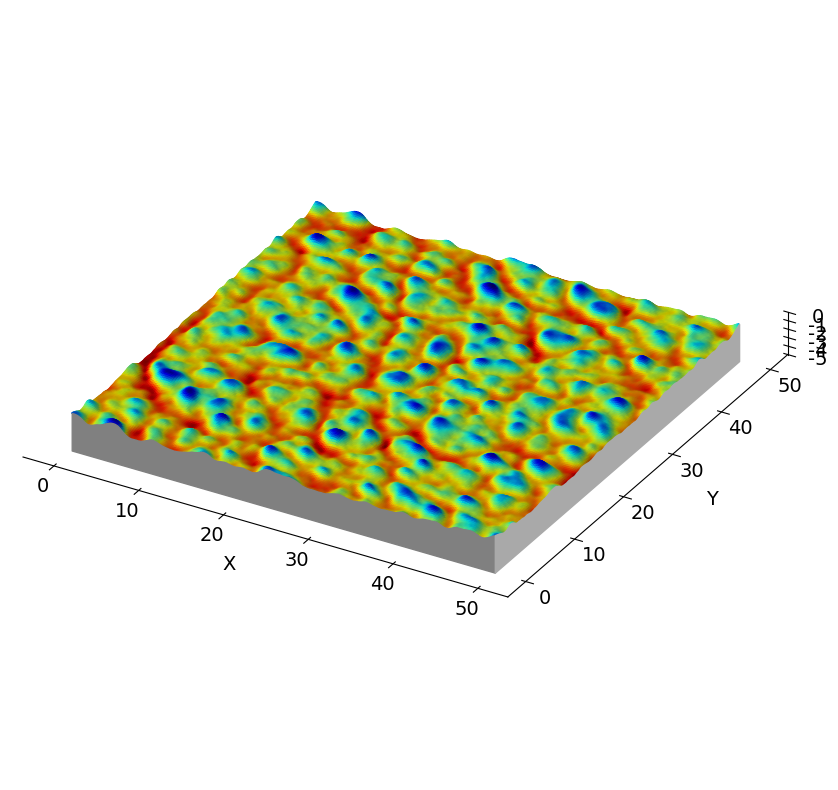

In [3]:
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

plt.rcParams.update({'font.size': 14})

# Load the initial and final maps to determine bounds
elevation_map = np.load('SIfig05/maps/elevation_map_0.npy')
trampled = np.load('SIfig05/maps/trampled_0_50_3_9.npy')

z_min = elevation_map.min() - 50  # Adjust to control the depth

# Determine the z-bounds for plotting
max_height = np.max(elevation_map)
min_height = z_min

# Determine the color bounds for the colormap
difference = elevation_map - trampled
max_erosion = np.max(difference)
min_erosion = np.min(difference)
norm = plt.Normalize(min_erosion, max_erosion)

# Scale tick labels by 10
def scale_ticks(val, pos):
    return f'{int(val / 10)}'

# Create a grid for the surface plot
x = np.arange(elevation_map.shape[0])
y = np.arange(elevation_map.shape[1])
x, y = np.meshgrid(x, y)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d', proj_type='ortho')

colors = plt.cm.jet(norm(difference))
ax.plot_surface(x, y, trampled, facecolors=colors, cstride=2, rstride=2)

# Define and add the side "walls" using Poly3DCollection
verts_bottom = [
    # Bottom edge wall
    [(x[0, i], y[0, i], trampled[0, i]) for i in range(x.shape[1])] +
    [(x[0, i], y[0, i], z_min) for i in range(x.shape[1])][::-1],
]
verts_right = [
    # Right edge wall
    [(x[i, -1], y[i, -1], trampled[i, -1]) for i in range(x.shape[0])] +
    [(x[i, -1], y[i, -1], z_min) for i in range(x.shape[0])][::-1]
]
# Add walls as polygons with Poly3DCollection
poly_bottom = Poly3DCollection(verts_bottom, color='gray', alpha=1)
ax.add_collection3d(poly_bottom)
poly_right = Poly3DCollection(verts_right, color='darkgray', alpha=1)
ax.add_collection3d(poly_right)

ax.set_zlim(min_height, max_height)

# Scale tick labels by 10
def scale_ticks(val, pos):
    return f'{int(val / 10)}'

ax.set_aspect('equal')

ax.xaxis.set_major_formatter(FuncFormatter(scale_ticks))
ax.yaxis.set_major_formatter(FuncFormatter(scale_ticks))
ax.zaxis.set_major_formatter(FuncFormatter(scale_ticks))

ax.set_xlabel('X', labelpad=17)
ax.set_ylabel('Y', labelpad=17)
ax.set_zlabel('Z', labelpad=10)

ax.grid(False)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

#ax.set_box_aspect(None, zoom=0.85)

#plt.savefig('Figures/coherence_trampled.png', transparent=True, bbox_inches='tight')

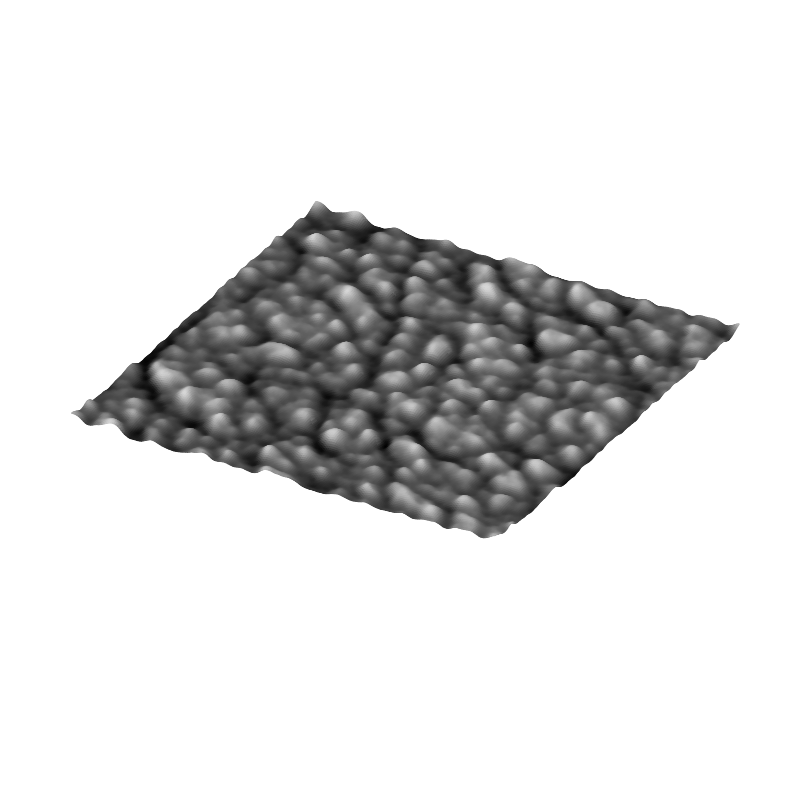

In [4]:
plt.rcParams.update({'font.size': 14})

# Load the initial and final maps to determine bounds
elevation_map = np.load('SIfig05/maps/elevation_map_0.npy')
trampled = np.load('SIfig05/maps/trampled_0_50_3_9.npy')

z_min = elevation_map.min() - 50  # Adjust to control the depth

# Determine the z-bounds for plotting
max_height = np.max(elevation_map)
min_height = z_min

# Determine the color bounds for the colormap
difference = elevation_map - trampled
max_erosion = np.max(difference)
min_erosion = np.min(difference)
norm = plt.Normalize(min_erosion, max_erosion)

# Scale tick labels by 10
def scale_ticks(val, pos):
    return f'{int(val / 10)}'

# Create a grid for the surface plot
x = np.arange(elevation_map.shape[0])
y = np.arange(elevation_map.shape[1])
x, y = np.meshgrid(x, y)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d', proj_type='ortho')

colors = plt.cm.Greys(norm(difference))
ax.plot_surface(x, y, -difference, facecolors=colors, cstride=2, rstride=2)

ax.set_zlim(min_height, max_height)

ax.xaxis.set_major_formatter(FuncFormatter(scale_ticks))
ax.yaxis.set_major_formatter(FuncFormatter(scale_ticks))
ax.zaxis.set_major_formatter(FuncFormatter(scale_ticks))

ax.set_xlabel('X', labelpad=17)
ax.set_ylabel('Y', labelpad=17)
ax.set_zlabel('Z', labelpad=10)

ax.grid(False)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax.axis('off')

ax.set_aspect('equal')

#ax.set_box_aspect(None, zoom=0.85)

#plt.savefig('Figures/coherence_surface.png', transparent=True, bbox_inches='tight')

In [ ]:
omegas = np.array([5, 10, 15, 20])

c_list = []
o_list = []
b_list = []
a_list = []

repeats = 10

N = 3
betas = np.array([50])
A = np.array([0, 10, 20, 30, 40])

np_df = np.genfromtxt('SIfig05/results.csv', delimiter=',')

for amplitude in A:
    for b in betas:
        for repeat in range(repeats): 
                
            np_df = np.genfromtxt('SIfig05/results.csv', delimiter=',')
            elevation_map = np.load(f'SIfig05/maps/elevation_map_{amplitude}.npy') 
            trampled = np.load(f'SIfig05/maps/trampled_{amplitude}_{b}_3_{repeat}.npy')
            total_erosion = trampled-elevation_map
            total_erosion = -(total_erosion - np.max(total_erosion))

            for i, omega in enumerate(omegas): 
                omega = int(omega)

                theta, mean_gradient, mean_coherence = fingerprint(total_erosion, omega, ground_truth=None, plot=False)
                
                c_list.append(mean_coherence)
                o_list.append(omega)
                b_list.append(b)
                a_list.append(amplitude)

            print(amplitude, b, repeat)


omegadf = pd.DataFrame({'alpha': a_list, 'coherence': c_list, 'omega': o_list})

0 50 0
0 50 1
0 50 2
0 50 3
0 50 4
0 50 5
0 50 6
0 50 7
0 50 8
0 50 9
10 50 0
10 50 1
10 50 2
10 50 3
10 50 4
10 50 5
10 50 6
10 50 7
10 50 8
10 50 9
20 50 0
20 50 1
20 50 2
20 50 3
20 50 4
20 50 5
20 50 6
20 50 7
20 50 8
20 50 9
30 50 0
30 50 1
30 50 2
30 50 3
30 50 4
30 50 5
30 50 6
30 50 7
30 50 8
30 50 9
40 50 0
40 50 1
40 50 2
40 50 3
40 50 4
40 50 5
40 50 6
40 50 7
40 50 8
40 50 9


([<matplotlib.axis.XTick at 0x78dca7822b60>,
 [Text(0, 0, '0.5'), Text(1, 0, '1.0'), Text(2, 0, '1.5'), Text(3, 0, '2.0')])

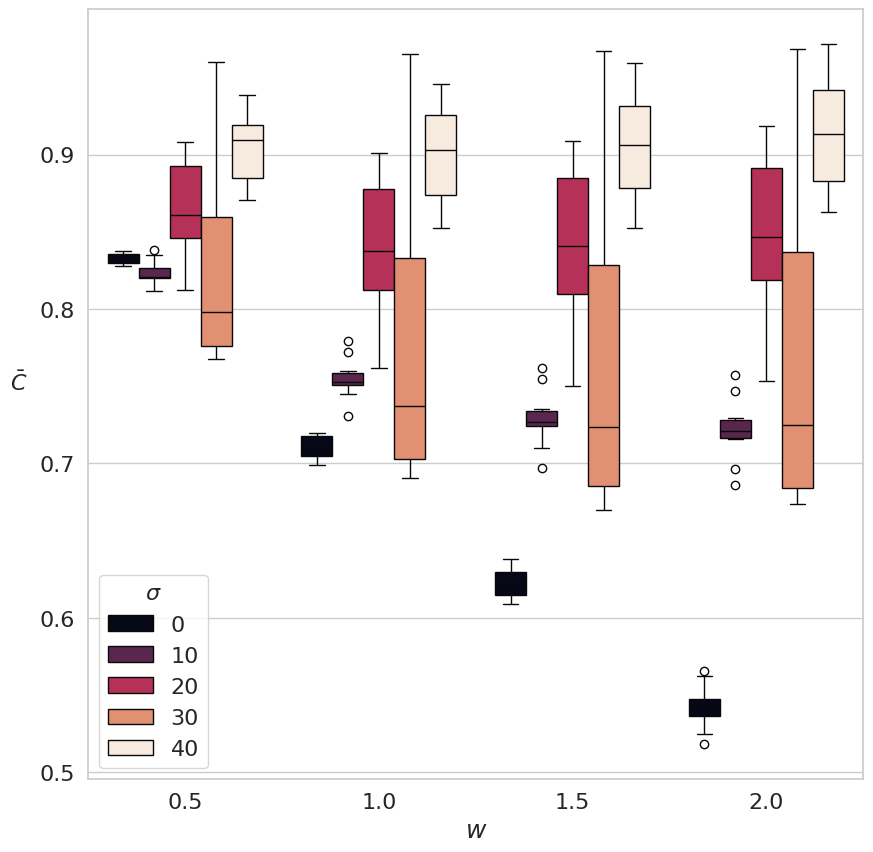

In [6]:
import seaborn as sns

sns.set_theme(style="whitegrid")

# Initialize the figure
f, ax = plt.subplots(figsize=(10,10))
#sns.despine(bottom=True, left=True)
# Show each observation with a scatterplot
sns.boxplot(data=omegadf, x="omega", y="coherence", hue="alpha", palette='rocket'
)

plt.xlabel(r"$w$", fontsize=18)
plt.ylabel(r"$\bar{C}$", rotation=0, fontsize=16, labelpad=15)
plt.legend(title=r"$\sigma$", title_fontsize=16, fontsize=16, loc='lower left')
plt.yticks(fontsize=16)
original_ticks = plt.xticks()[0]  # Get original tick positions
scaled_labels = [0.5, 1.0, 1.5, 2.0]  # Divide by 10 and format
plt.xticks(ticks=original_ticks, labels=scaled_labels, fontsize=16)

# plt.savefig('Figures/window_selection.png', transparent=True, bbox_inches='tight')
